# 6CS012 – Final Portfolio Assessment 2026
## Part III: Language Tasks — Sentiment Analysis with RNN / LSTM
### Dataset: Book Reviews (12,000 records, Ratings 1–5)


## 0. Setup & Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re, string, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


---
## 4.5.1 Text Preprocessing, Tokenization & Padding
### Load Dataset

In [3]:
# ── Load CSV ──────────────────────────────────────────────────────────────────
CSV_PATH = '/content/drive/MyDrive/AI ML/Book_review.csv'   # adjust if needed
df = pd.read_csv(CSV_PATH)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nFirst 3 rows:')
df[['rating', 'reviewText']].head(3)

Shape: (12000, 4)
Columns: ['Unnamed: 0', 'rating', 'reviewText', 'summary']

First 3 rows:


,rating,reviewText
0,5,This book was the very first bookmobile book I...
1,1,"When I read the description for this book, I c..."
2,5,I just had to edit this review. This book is a...


In [4]:
# ── Basic EDA ─────────────────────────────────────────────────────────────────
print('Rating distribution:')
print(df['rating'].value_counts().sort_index())
print('\nNull values:')
print(df.isnull().sum())

# Drop rows where reviewText is null
df.dropna(subset=['reviewText'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'\nAfter dropping nulls: {df.shape}')

Rating distribution:
rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64

Null values:
Unnamed: 0    0
rating        0
reviewText    0
summary       2
dtype: int64

After dropping nulls: (12000, 4)


Sentiment distribution:
sentiment
0    4000
1    2000
2    6000
Name: count, dtype: int64


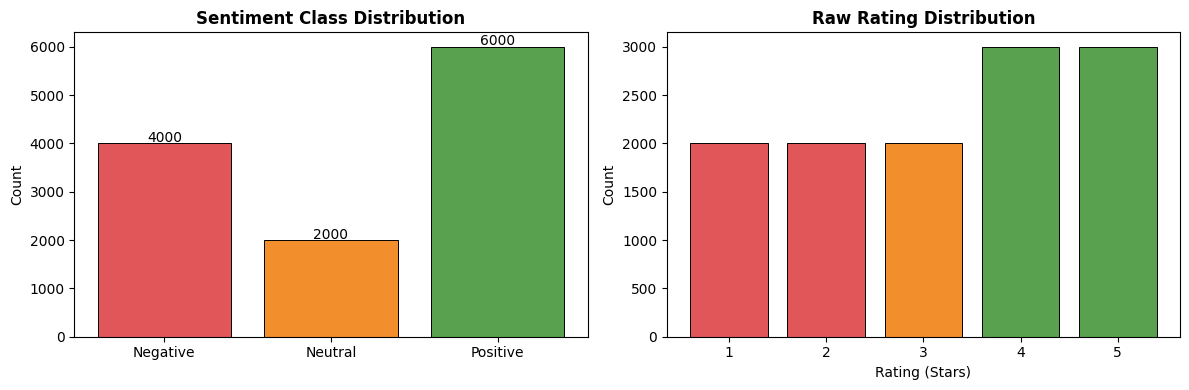

In [5]:
# ── Convert rating → 3-class sentiment ───────────────────────────────────────
# 1–2 → Negative (0) | 3 → Neutral (1) | 4–5 → Positive (2)
def rating_to_sentiment(r):
    if r <= 2: return 0    # Negative
    elif r == 3: return 1  # Neutral
    else: return 2         # Positive

df['sentiment'] = df['rating'].apply(rating_to_sentiment)
sentiment_names  = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

print('Sentiment distribution:')
print(df['sentiment'].value_counts().sort_index())

# ── Visualise class distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#e15759', '#f28e2b', '#59a14f']
sent_counts = df['sentiment'].value_counts().sort_index()
axes[0].bar([sentiment_names[k] for k in sent_counts.index], sent_counts.values,
            color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Sentiment Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center')

rating_counts = df['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index.astype(str), rating_counts.values,
            color=['#e15759','#e15759','#f28e2b','#59a14f','#59a14f'],
            edgecolor='black', linewidth=0.7)
axes[1].set_title('Raw Rating Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rating (Stars)'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

### Text Cleaning

In [6]:
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

# Common contractions
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "won't": "will not", "wouldn't": "would not",
    "can't": "cannot", "couldn't": "could not", "shouldn't": "should not",
    "it's": "it is", "i'm": "i am", "i've": "i have", "i'll": "i will",
    "i'd": "i would", "you're": "you are", "you've": "you have",
    "they're": "they are", "we're": "we are", "we've": "we have",
    "that's": "that is", "there's": "there is", "what's": "what is",
    "let's": "let us"
}

def clean_text(text: str) -> str:
    """Full NLP preprocessing pipeline."""
    text = str(text).lower()                              # lowercase
    for cont, exp in CONTRACTIONS.items():                # expand contractions
        text = text.replace(cont, exp)
    text = re.sub(r'http\S+|www\S+', '', text)            # remove URLs
    text = re.sub(r'@\w+', '', text)                      # remove @mentions
    text = re.sub(r'#\w+', '', text)                      # remove hashtags
    text = re.sub(r'\d+', '', text)                       # remove numbers
    text = re.sub(r'[^\w\s]', ' ', text)                  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()              # collapse whitespace
    # tokenise, remove stopwords, lemmatise
    tokens = [lemmatizer.lemmatize(w)
              for w in text.split()
              if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

print('Cleaning texts …')
df['clean_text'] = df['reviewText'].apply(clean_text)
print('Done!')
print('\nBefore:', df['reviewText'].iloc[1][:200])
print('\nAfter: ', df['clean_text'].iloc[1][:200])

Cleaning texts …
Done!

Before: When I read the description for this book, I couldn't wait to read it. Once I downloaded it to my Kindle, I found it extremely hard to keep reading it.  To be honest, I stopped reading halfway through

After:  read description book could wait read downloaded kindle found extremely hard keep reading honest stopped reading halfway book began slow remained slow uninteresting read lacked passion making love pas


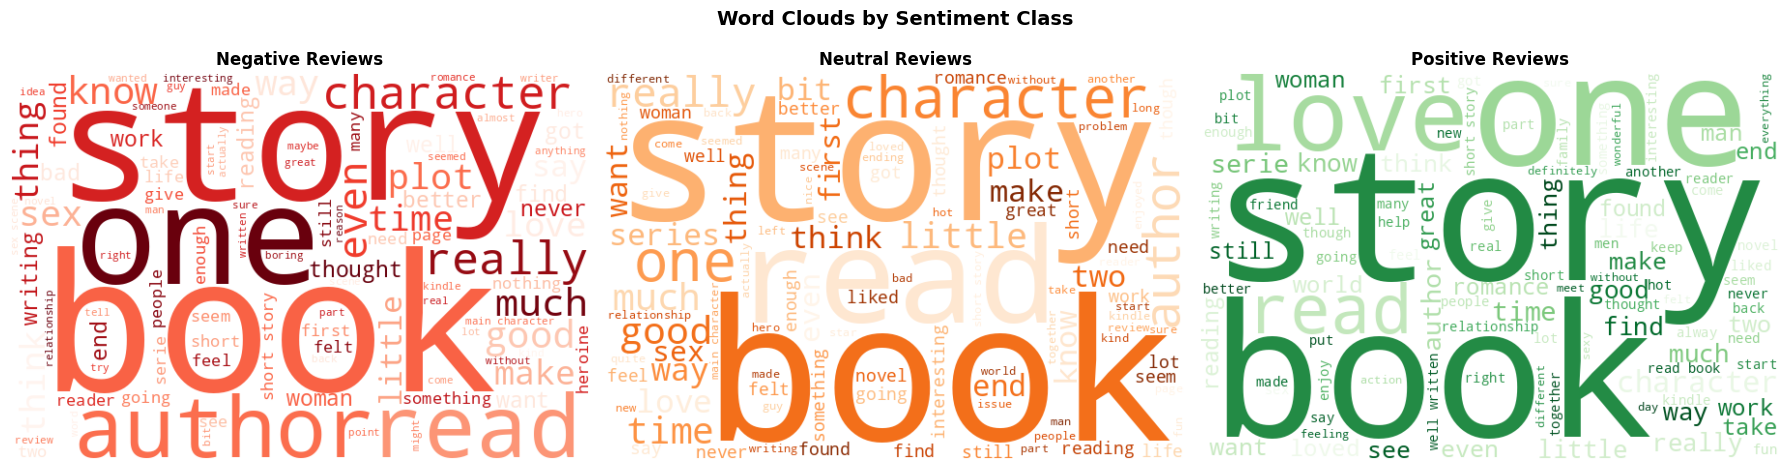

In [7]:
# ── Word Cloud visualization ──────────────────────────────────────────────────
try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sentiment_colors = {0: 'Reds', 1: 'Oranges', 2: 'Greens'}

    for sent_id, cmap in sentiment_colors.items():
        text_corpus = ' '.join(df[df['sentiment']==sent_id]['clean_text'].values)
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap=cmap, max_words=100).generate(text_corpus)
        axes[sent_id].imshow(wc, interpolation='bilinear')
        axes[sent_id].axis('off')
        axes[sent_id].set_title(f'{sentiment_names[sent_id]} Reviews',
                                 fontsize=12, fontweight='bold')

    plt.suptitle('Word Clouds by Sentiment Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('wordclouds.png', dpi=120, bbox_inches='tight')
    plt.show()
except ImportError:
    print('wordcloud not available – skipping')

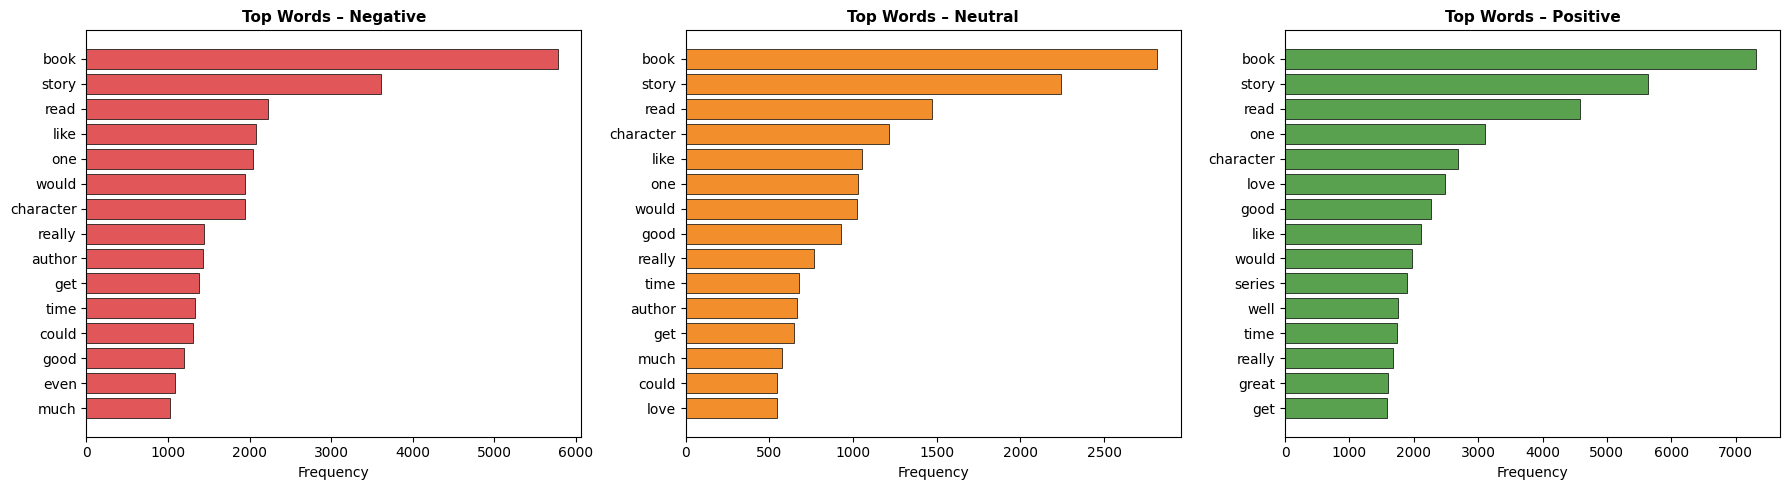

In [8]:
# ── Most frequent words per class ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_list = ['#e15759','#f28e2b','#59a14f']

for sent_id in range(3):
    words = ' '.join(df[df['sentiment']==sent_id]['clean_text']).split()
    top20 = Counter(words).most_common(15)
    w, c = zip(*top20)
    axes[sent_id].barh(list(reversed(w)), list(reversed(c)),
                       color=colors_list[sent_id], edgecolor='black', linewidth=0.5)
    axes[sent_id].set_title(f'Top Words – {sentiment_names[sent_id]}',
                             fontsize=11, fontweight='bold')
    axes[sent_id].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=120, bbox_inches='tight')
plt.show()

### Tokenization & Padding

In [9]:
# ── Train / Test split (80/20) ────────────────────────────────────────────────
X = df['clean_text'].values
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print('Train sentiment distribution:', Counter(y_train))
print('Test  sentiment distribution:', Counter(y_test))

Train: 9600 | Test: 2400
Train sentiment distribution: Counter({np.int64(2): 4800, np.int64(0): 3200, np.int64(1): 1600})
Test  sentiment distribution: Counter({np.int64(2): 1200, np.int64(0): 800, np.int64(1): 400})


In [10]:
# ── Tokenization ──────────────────────────────────────────────────────────────
VOCAB_SIZE = 15000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

train_seqs = tokenizer.texts_to_sequences(X_train)
test_seqs  = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index
print(f'Vocabulary size (fitted): {len(word_index):,}')
print(f'Top 10 words: {list(word_index.items())[:10]}')

Vocabulary size (fitted): 23,912
Top 10 words: [('<OOV>', 1), ('book', 2), ('story', 3), ('read', 4), ('one', 5), ('character', 6), ('like', 7), ('would', 8), ('good', 9), ('really', 10)]


Sequence length stats – mean: 53, median: 29, 90th pct: 128


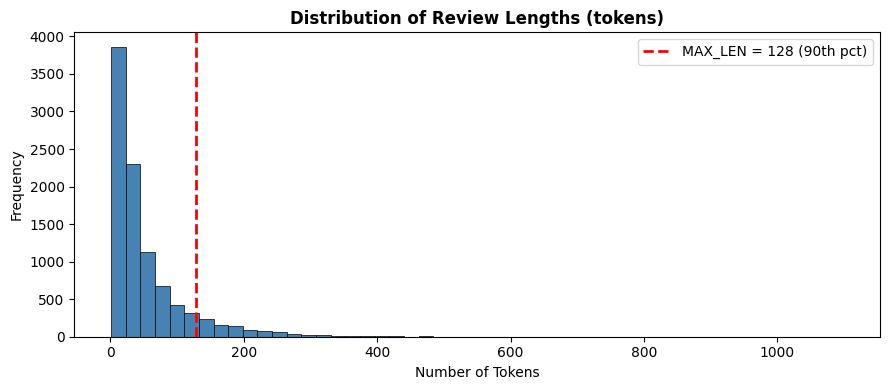

X_train_pad shape: (9600, 128)
X_test_pad  shape: (2400, 128)


In [11]:
# ── Percentile-based padding ───────────────────────────────────────────────────
lengths = [len(s) for s in train_seqs]
MAX_LEN = int(np.percentile(lengths, 90))   # 90th percentile to avoid extreme outliers
print(f'Sequence length stats – mean: {np.mean(lengths):.0f}, '
      f'median: {np.median(lengths):.0f}, 90th pct: {MAX_LEN}')

# ── Plot sequence length distribution ────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black', linewidth=0.5)
plt.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2,
            label=f'MAX_LEN = {MAX_LEN} (90th pct)')
plt.title('Distribution of Review Lengths (tokens)', fontsize=12, fontweight='bold')
plt.xlabel('Number of Tokens'); plt.ylabel('Frequency')
plt.legend(); plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=120, bbox_inches='tight')
plt.show()

X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad  shape: {X_test_pad.shape}')

In [12]:
# ── Class weights ─────────────────────────────────────────────────────────────
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights_arr))
print('Class weights:', {sentiment_names[k]: round(v, 3) for k, v in class_weights.items()})

NUM_CLASSES  = 3
EMBED_DIM    = 64
BATCH_SIZE   = 64
EPOCHS       = 20

Class weights: {'Negative': np.float64(1.0), 'Neutral': np.float64(2.0), 'Positive': np.float64(0.667)}


---
## 4.5.2 Model Building
### Model 1 — Simple RNN with Trainable Embedding

In [13]:
rnn_model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     input_length=MAX_LEN, name='embedding_rnn'),
    layers.SimpleRNN(64, return_sequences=True, name='rnn_1'),
    layers.SimpleRNN(32, name='rnn_2'),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='SimpleRNN_Model')

rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (SimpleRNN)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (SimpleRNN)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM with Trainable Embedding

In [14]:
lstm_model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     input_length=MAX_LEN, name='embedding_lstm'),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True), name='bilstm_1'),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.LSTM(32), name='bilstm_2'),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_Model')

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 3 — LSTM with Pre-trained GloVe / Word2Vec Embeddings

In [18]:
# ── Download GloVe embeddings (via gensim) ────────────────────────────────────
!pip install gensim
import gensim.downloader as gensim_api

print('Downloading glove-wiki-gigaword-50 (≈70MB) – may take a few minutes …')
embedding_model = gensim_api.load('glove-wiki-gigaword-50')   # 50-dim GloVe
GLOVE_DIM = 50
print('Downloaded!')

Downloaded!


In [19]:
# ── Build embedding matrix ────────────────────────────────────────────────────
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
hits = misses = 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        hits += 1
    else:
        misses += 1

coverage = hits / (hits + misses) * 100
print(f'Hits: {hits} | Misses: {misses} | Coverage: {coverage:.1f}%')

Hits: 14252 | Misses: 747 | Coverage: 95.0%


In [20]:
# ── LSTM with pre-trained GloVe ───────────────────────────────────────────────
lstm_w2v = keras.Sequential([
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,          # freeze pre-trained weights
        name='glove_embedding'
    ),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True), name='bilstm_w2v_1'),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.LSTM(32), name='bilstm_w2v_2'),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_GloVe_Model')

lstm_w2v.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │       750,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_w2v_1 (Bidirectional)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_w2v_2 (Bidirectional)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 750,000 (2.86 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 750,000 (2.86 MB)

---
## 4.5.3 Model Training & Evaluation
### Helper: compile + train + evaluate

In [21]:
def compile_and_train(model, name, X_train, y_train, X_test, y_test,
                      epochs=EPOCHS, batch_size=BATCH_SIZE):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ]
    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=epochs, batch_size=batch_size,
        validation_split=0.15,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    train_time = time.time() - t0

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred    = np.argmax(model.predict(X_test, verbose=0), axis=1)

    print(f'\n{name} – Test Loss: {loss:.4f} | Test Acc: {acc*100:.2f}% | Time: {train_time:.0f}s')
    print(classification_report(y_test, y_pred,
                                 target_names=list(sentiment_names.values())))
    return history, y_pred, acc, train_time

In [22]:
# ── Train Model 1: SimpleRNN ──────────────────────────────────────────────────
hist_rnn, pred_rnn, acc_rnn, time_rnn = compile_and_train(
    rnn_model, 'SimpleRNN', X_train_pad, y_train, X_test_pad, y_test
)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.3097 - loss: 1.1168 - val_accuracy: 0.3285 - val_loss: 1.1001 - learning_rate: 0.0010
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3342 - loss: 1.1085 - val_accuracy: 0.3125 - val_loss: 1.1044 - learning_rate: 0.0010
Epoch 3/20
127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3418 - loss: 1.1012
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3248 - loss: 1.1054 - val_accuracy: 0.3056 - val_loss: 1.1012 - learning_rate: 0.0010
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3138 - loss: 1.1037 - val_accuracy: 0.2576 - val_loss: 1.1115 - learning_rate: 5.0000e-04
Epoch 5/20
126/128 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3189 - loss: 1.0994
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3147 - loss:

In [23]:
# ── Train Model 2: LSTM ───────────────────────────────────────────────────────
hist_lstm, pred_lstm, acc_lstm, time_lstm = compile_and_train(
    lstm_model, 'LSTM', X_train_pad, y_train, X_test_pad, y_test
)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.5103 - loss: 1.0135 - val_accuracy: 0.6826 - val_loss: 0.8037 - learning_rate: 0.0010
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7091 - loss: 0.7845 - val_accuracy: 0.6354 - val_loss: 0.8420 - learning_rate: 0.0010
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7582 - loss: 0.6464
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.7610 - loss: 0.6317 - val_accuracy: 0.6792 - val_loss: 0.8327 - learning_rate: 0.0010
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8602 - loss: 0.4118 - val_accuracy: 0.6521 - val_loss: 0.9384 - learning_rate: 5.0000e-04
Epoch 5/20
127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9091 - loss: 0.3014
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9152 - loss:

In [24]:
# ── Train Model 3: LSTM + GloVe ───────────────────────────────────────────────
hist_w2v, pred_w2v, acc_w2v, time_w2v = compile_and_train(
    lstm_w2v, 'LSTM+GloVe', X_train_pad, y_train, X_test_pad, y_test
)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.5271 - loss: 1.0328 - val_accuracy: 0.5701 - val_loss: 0.9696 - learning_rate: 0.0010
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5887 - loss: 0.9656 - val_accuracy: 0.5549 - val_loss: 0.9891 - learning_rate: 0.0010
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6064 - loss: 0.9321 - val_accuracy: 0.5701 - val_loss: 0.9690 - learning_rate: 0.0010
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6125 - loss: 0.9067 - val_accuracy: 0.6000 - val_loss: 0.9328 - learning_rate: 0.0010
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6080 - loss: 0.8986 - val_accuracy: 0.5924 - val_loss: 0.9147 - learning_rate: 0.0010
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6227 - loss: 0.8742 - val_accuracy: 0.6062 - val_loss: 0.8976 - learning_rate: 0.0010
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6365 - loss: 0.

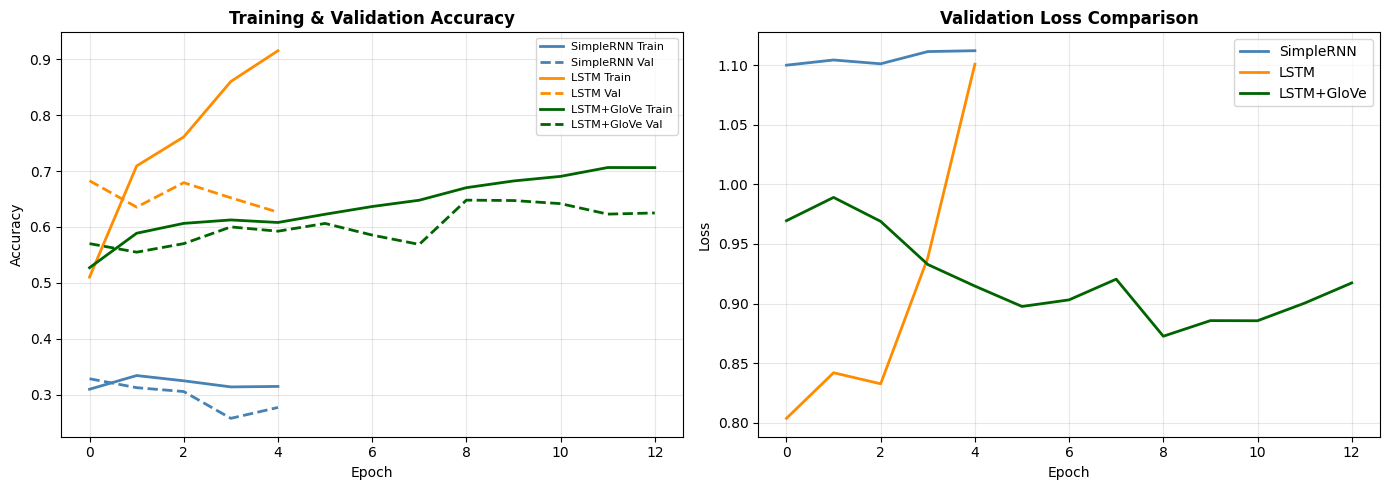

In [25]:
# ── Plot training curves for all 3 models ────────────────────────────────────
def plot_all_histories(histories, names, colors, metric='accuracy', save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    val_metric = f'val_{metric}'
    for hist, name, color in zip(histories, names, colors):
        axes[0].plot(hist.history[metric],     label=f'{name} Train', lw=2, color=color)
        axes[0].plot(hist.history[val_metric], label=f'{name} Val',   lw=2,
                     color=color, linestyle='--')
        axes[1].plot(hist.history['val_loss'], label=name, lw=2, color=color)

    axes[0].set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Validation Loss Comparison', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()

plot_all_histories(
    [hist_rnn, hist_lstm, hist_w2v],
    ['SimpleRNN', 'LSTM', 'LSTM+GloVe'],
    ['steelblue', 'darkorange', 'darkgreen'],
    save_name='nlp_training_curves.png'
)

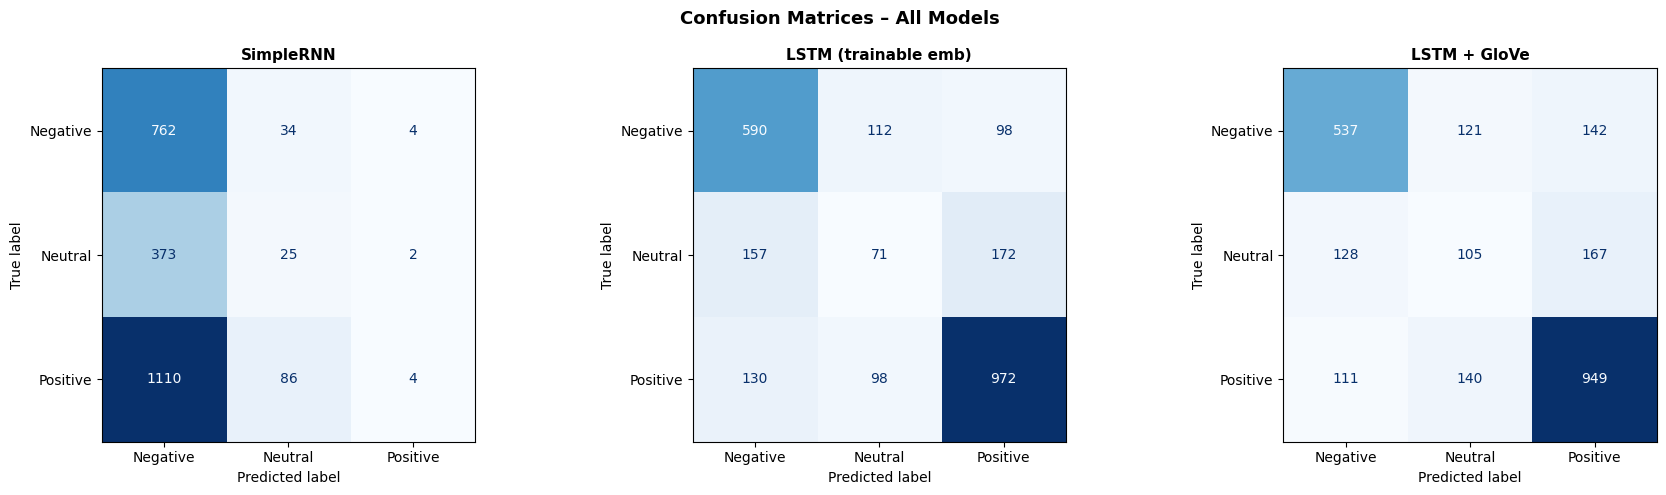

In [26]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names_list = ['SimpleRNN', 'LSTM (trainable emb)', 'LSTM + GloVe']
preds_list = [pred_rnn, pred_lstm, pred_w2v]

for ax, preds, name in zip(axes, preds_list, model_names_list):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=list(sentiment_names.values()))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices – All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nlp_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

       Model  Test Acc (%)  Train Time (s)
   SimpleRNN         32.96              34
        LSTM         68.04              29
LSTM + GloVe         66.29              55


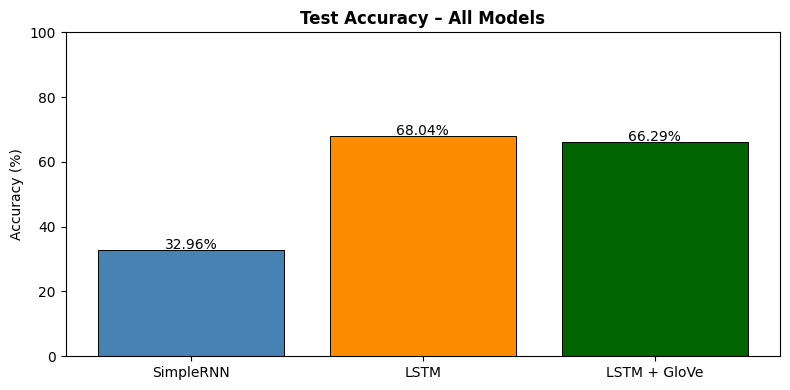

In [27]:
# ── Final performance summary ─────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Model'         : ['SimpleRNN', 'LSTM', 'LSTM + GloVe'],
    'Test Acc (%)'  : [round(acc_rnn*100, 2), round(acc_lstm*100, 2),
                       round(acc_w2v*100, 2)],
    'Train Time (s)': [round(time_rnn), round(time_lstm), round(time_w2v)]
})
print(summary_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(summary_df['Model'], summary_df['Test Acc (%)'],
              color=['steelblue', 'darkorange', 'darkgreen'],
              edgecolor='black', linewidth=0.7)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.2f}%", ha='center', fontsize=10)
ax.set_title('Test Accuracy – All Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('nlp_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4.5.4 Error Analysis

In [28]:
# ── Find and display misclassified examples ───────────────────────────────────
best_preds = pred_w2v   # use best model (LSTM+GloVe)
wrong_idx  = np.where(best_preds != y_test)[0]

print(f'Total misclassified: {len(wrong_idx)} / {len(y_test)} '
      f'({len(wrong_idx)/len(y_test)*100:.1f}%)')

# Reconstruct test texts for display
X_test_texts = np.array(X)[np.array(range(len(X)))]  # original clean texts
_, X_test_raw, _, y_test_check = train_test_split(
    df['reviewText'].values, y, test_size=0.2, random_state=42, stratify=y
)
_, X_test_clean_arr = train_test_split(
    df['clean_text'].values, test_size=0.2, random_state=42, stratify=y
)

print('\n=== Sample Misclassified Reviews ===')
shown = 0
for idx in wrong_idx[:20]:
    true_lbl = sentiment_names[y_test[idx]]
    pred_lbl = sentiment_names[best_preds[idx]]
    snippet  = X_test_raw[idx][:200]
    print(f'\n[Example {shown+1}]')
    print(f'  True : {true_lbl} | Predicted : {pred_lbl}')
    print(f'  Text : "{snippet}…"')
    shown += 1
    if shown >= 3:
        break

Total misclassified: 809 / 2400 (33.7%)

=== Sample Misclassified Reviews ===

[Example 1]
  True : Negative | Predicted : Neutral
  Text : "I thought with all the positive reviews I would love this book.  Not! This book is horrible it starts fast (literally she is in love with one man in the morning and in love with another by the evening…"

[Example 2]
  True : Negative | Predicted : Neutral
  Text : "Short and sweet.  A good short story with lots of sex.  If you like this type of book this is a good read.…"

[Example 3]
  True : Negative | Predicted : Positive
  Text : "Story drug in the beginning and had a quick ending.I will read his other book though  Beyond Justice. The end of this book has a few chapters of it and so far it's awesome.…"


In [29]:
# ── Error pattern analysis ────────────────────────────────────────────────────
error_df = pd.DataFrame({
    'True Label': [sentiment_names[y_test[i]] for i in wrong_idx],
    'Pred Label': [sentiment_names[best_preds[i]] for i in wrong_idx]
})
error_pivot = error_df.groupby(['True Label', 'Pred Label']).size().reset_index(name='Count')
print('Error pattern (True → Predicted):')
print(error_pivot.to_string(index=False))

print('\n=== Reasons for Errors ===')
print('1. Neutral class (rating=3) is ambiguous; many neutral reviews contain mixed sentiments.')
print('2. Sarcasm and irony in negative reviews can be incorrectly classified as positive.')
print('3. OOV (out-of-vocabulary) words not present in GloVe cause zero embeddings.')
print('4. Very long reviews get truncated, losing important context.')
print('\n=== Suggested Improvements ===')
print('1. Use fine-tuned BERT / transformer-based models for better context understanding.')
print('2. Merge neutral class with nearest class (binary or asymmetric weighting).')
print('3. Increase MAX_LEN or use hierarchical attention networks for long texts.')
print('4. Try domain-specific embeddings trained on book/product review corpora.')

Error pattern (True → Predicted):
True Label Pred Label  Count
  Negative    Neutral    121
  Negative   Positive    142
   Neutral   Negative    128
   Neutral   Positive    167
  Positive   Negative    111
  Positive    Neutral    140

=== Reasons for Errors ===
1. Neutral class (rating=3) is ambiguous; many neutral reviews contain mixed sentiments.
2. Sarcasm and irony in negative reviews can be incorrectly classified as positive.
3. OOV (out-of-vocabulary) words not present in GloVe cause zero embeddings.
4. Very long reviews get truncated, losing important context.

=== Suggested Improvements ===
1. Use fine-tuned BERT / transformer-based models for better context understanding.
2. Merge neutral class with nearest class (binary or asymmetric weighting).
3. Increase MAX_LEN or use hierarchical attention networks for long texts.
4. Try domain-specific embeddings trained on book/product review corpora.


---
## 4.5.5 GUI for Real-Time Prediction (Gradio)

In [30]:
# ── Real-Time Prediction GUI with Gradio ──────────────────────────────────────
import gradio as gr

def predict_sentiment(review_text: str) -> dict:
    """Clean, tokenize, pad and predict sentiment."""
    if not review_text.strip():
        return {'Error': 1.0}

    cleaned  = clean_text(review_text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs    = lstm_w2v.predict(padded, verbose=0)[0]

    return {
        '😡 Negative': float(probs[0]),
        '😐 Neutral' : float(probs[1]),
        '😊 Positive': float(probs[2])
    }

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder='Enter a book review here …',
        label='Book Review Text'
    ),
    outputs=gr.Label(num_top_classes=3, label='Sentiment Probabilities'),
    title='📚 Book Review Sentiment Analyser',
    description=(
        'Enter any book review and the LSTM+GloVe model will classify it as '
        'Positive, Neutral, or Negative.'
    ),
    examples=[
        ['This book was absolutely wonderful! Engaging plot and beautiful writing.'],
        ['The story was okay, nothing special, neither great nor terrible.'],
        ['I was very disappointed. Slow pace, flat characters, not worth the time.']
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)   # share=True gives a public link in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://53610d574c6506c390.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Summary & Observations

| Model   | Architecture | Embedding         | Test Accuracy |
| ------- | ------------ | ----------------- | ------------- |
| Model 1 | SimpleRNN    | Trainable         | 32.96%        |
| Model 2 | Bi-LSTM      | Trainable         | 68.04%        |
| Model 3 | Bi-LSTM      | GloVe-50 (Frozen) | 66.29%        |


**Key Takeaways:**
1. **Bi-LSTM significantly outperformed SimpleRNN** because LSTM networks are better at capturing long-term dependencies and reducing the vanishing gradient problem in sequential text data.
2. The **SimpleRNN model showed poor generalization performance** indicating that basic recurrent networks struggle to learn complex sentiment patterns from long reviews and mixed expressions.
3. **Pretrained GloVe embeddings provided competitive results,** but the trainable embedding Bi-LSTM achieved slightly higher accuracy in this experiment, likely because it adapted better to the dataset-specific vocabulary.
4. The **Neutral class was the most difficult to classify** rsince many reviews contained both positive and negative opinions, making sentiment boundaries less distinct.
5. **Bidirectional LSTM layers improved contextual understanding**
by processing reviews from both forward and backward directions, helping the model capture richer semantic information.
6. **Validation accuracy stabilized faster in LSTM-based models,** showing that deeper recurrent architectures learn textual patterns more effectively than SimpleRNN models.